# Experiments for Paper Materials

Ноутбук запускает 5 сценариев из плана статьи, считает RecSys- и matching-метрики, сохраняет CSV, графики и кейсы в `paper_materials/`.


In [1]:
import os
import sys
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'paper_materials' else Path.cwd()
SRC_DIR = PROJECT_ROOT / 'src'
sys.path.insert(0, str(SRC_DIR))
sys.path.insert(0, str(PROJECT_ROOT / 'paper_materials'))
os.environ.setdefault('DJANGO_SETTINGS_MODULE', 'config.settings')
os.environ["DJANGO_ALLOW_ASYNC_UNSAFE"] = "true"
os.environ['POSTGRES_HOST'] = 'localhost'
os.environ['POSTGRES_PORT'] = '5433'  # проброс из docker-compose: 5433:5432

import django
django.setup()

%matplotlib inline

from utils import ExperimentConfig, load_django_dataset, parse_ground_truth_json, save_all_artifacts, save_ground_truth_prompt, show_experiment_plots

## Ground Truth

1. Следующая ячейка сохраняет промпт для внешней LLM, если нужен ручной аудит идеальных проектов.
2. Вставленный JSON-ответ можно передать в `LLM_GT_RESPONSE`.
3. Если ответ пустой, notebook использует контролируемый hidden relevance: теги + семантика + релевантные оценки, без popularity и capacity.

In [2]:
config = ExperimentConfig(students_limit=150, projects_limit=100, top_k=20, application_k=5, seed=42)
students, projects = load_django_dataset(config)
prompt_path = PROJECT_ROOT / 'paper_materials' / 'ground_truth_prompt.txt'
# save_ground_truth_prompt(prompt_path, students, projects, limit=150)
print(f'Промпт: {prompt_path} ({prompt_path.stat().st_size} байт)')
print(prompt_path.read_text(encoding='utf-8')[:1200], '...\n[полный текст в файле]')

Промпт: /Users/user/Desktop/Учеба/cursach/2025_hse_dsa/paper_materials/ground_truth_prompt.txt (266532 байт)
Подбери идеальный проект для каждого студента по смысловому соответствию профиля и проекта.
Верни строго JSON-массив без markdown, ровно для student_id: 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150.
[{"student_id": <int>, "ideal_project_id": <int>, "reason": "<коротко>"}]

Студенты:
- student_i

In [3]:
USE_LLM_GROUND_TRUTH = False
LLM_GT_RESPONSE = (PROJECT_ROOT / 'paper_materials' / 'ground_truth_result.txt').read_text(encoding='utf-8')

# По умолчанию используем контролируемый oracle-GT из utils.py.
# LLM-ответ оставлен для ручного аудита и может быть включен этой переменной.
ground_truth = (
    parse_ground_truth_json(LLM_GT_RESPONSE, students=students)
    if USE_LLM_GROUND_TRUTH and LLM_GT_RESPONSE.strip()
    else None
)
ground_truth

## Запуск 5 сценариев

Сценарии: Base, RecSys-only, RecSys + Prof. Rank, Hybrid, Stable Matching.

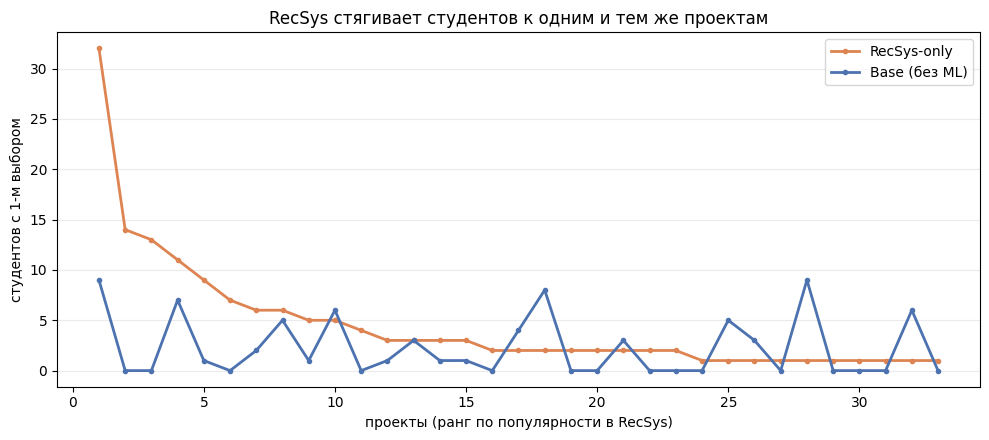

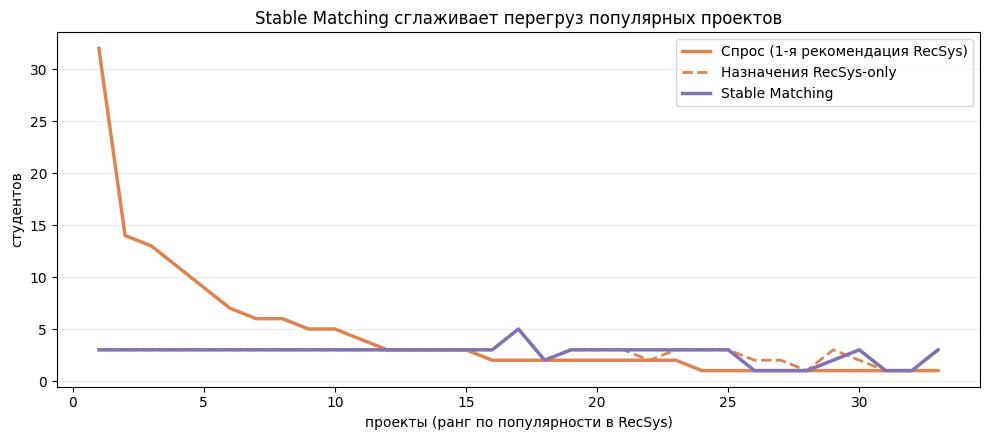

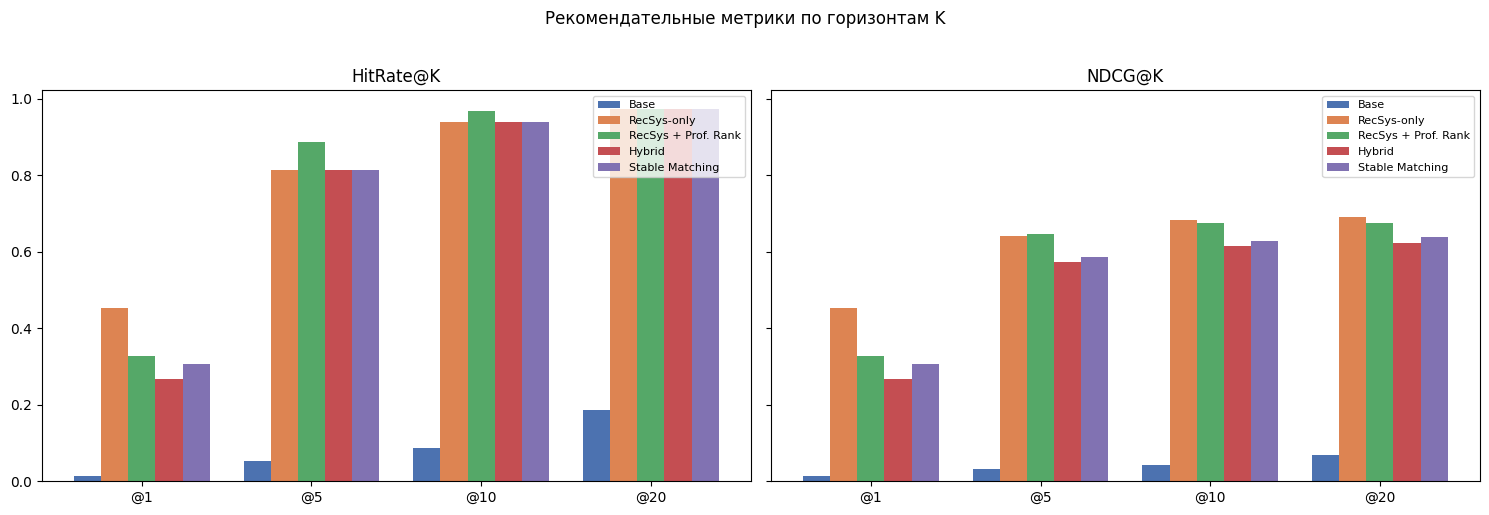

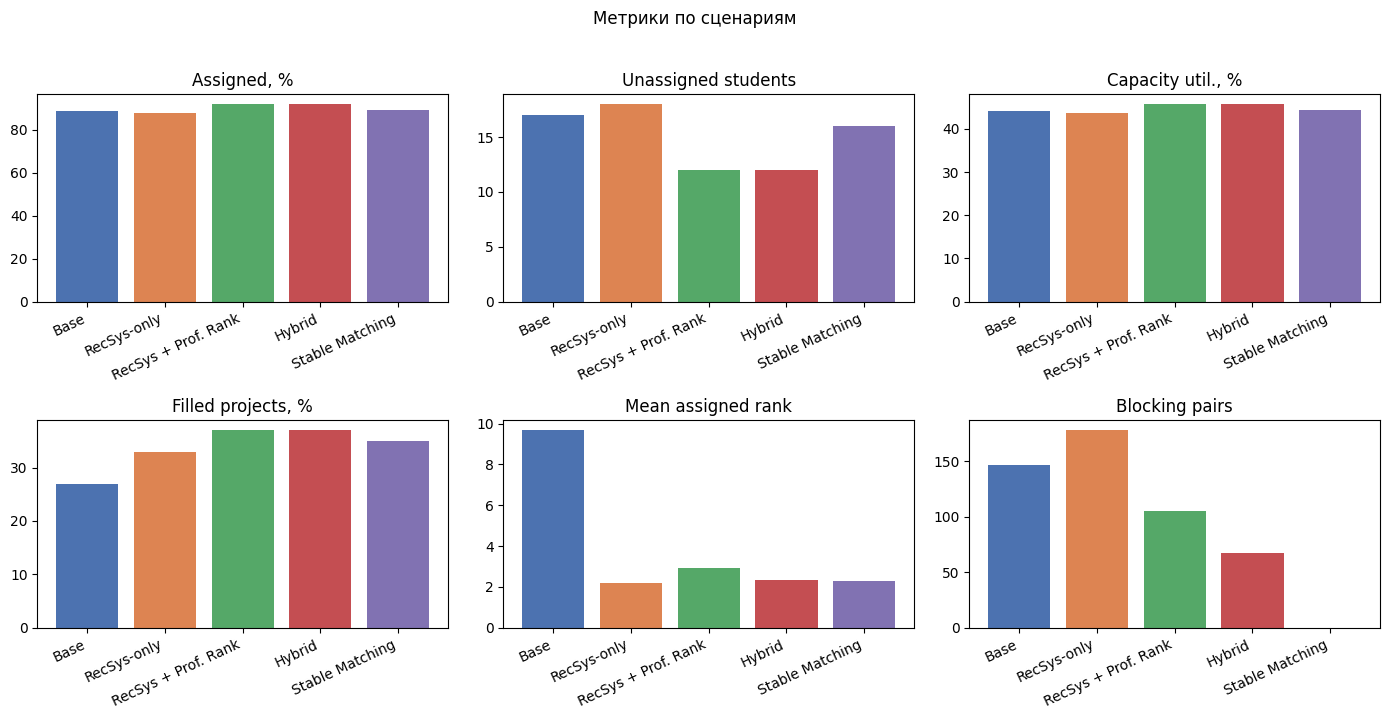

[{'scenario_id': 'base',
  'scenario_name': 'Base',
  'hit_rate_at_1': 0.0133,
  'ndcg_at_1': 0.0133,
  'hit_rate_at_5': 0.0533,
  'ndcg_at_5': 0.0322,
  'hit_rate_at_10': 0.0867,
  'ndcg_at_10': 0.0431,
  'hit_rate_at_20': 0.1867,
  'ndcg_at_20': 0.0682,
  'assigned_pct': 88.67,
  'unassigned_students': 17,
  'capacity_utilization_pct': 44.04,
  'filled_projects_pct': 27.0,
  'mean_student_rank_assigned': 9.68,
  'mrr_assigned': 0.176,
  'blocking_pairs': 147},
 {'scenario_id': 'recsys_only',
  'scenario_name': 'RecSys-only',
  'hit_rate_at_1': 0.4533,
  'ndcg_at_1': 0.4533,
  'hit_rate_at_5': 0.8133,
  'ndcg_at_5': 0.6417,
  'hit_rate_at_10': 0.94,
  'ndcg_at_10': 0.6833,
  'hit_rate_at_20': 0.9733,
  'ndcg_at_20': 0.692,
  'assigned_pct': 88.0,
  'unassigned_students': 18,
  'capacity_utilization_pct': 43.71,
  'filled_projects_pct': 33.0,
  'mean_student_rank_assigned': 2.19,
  'mrr_assigned': 0.6492,
  'blocking_pairs': 178},
 {'scenario_id': 'recsys_prof_rank',
  'scenario_name':

In [4]:
materials_dir = PROJECT_ROOT / 'paper_materials'
metrics, histograms = save_all_artifacts(
    materials_dir,
    config=config,
    ground_truth=ground_truth,
    show_plots=True,
)
metrics

In [5]:
display(pd.read_csv(materials_dir / 'results_table.csv'))

,scenario_id,scenario_name,hit_rate_at_1,ndcg_at_1,hit_rate_at_5,ndcg_at_5,hit_rate_at_10,ndcg_at_10,hit_rate_at_20,ndcg_at_20,assigned_pct,unassigned_students,capacity_utilization_pct,filled_projects_pct,mean_student_rank_assigned,mrr_assigned,blocking_pairs
0,base,Base,0.0133,0.0133,0.0533,0.0322,0.0867,0.0431,0.1867,0.0682,88.67,17,44.04,27.0,9.68,0.1760,147
1,recsys_only,RecSys-only,0.4533,0.4533,0.8133,0.6417,0.9400,0.6833,0.9733,0.6920,88.00,18,43.71,33.0,2.19,0.6492,178
2,recsys_prof_rank,RecSys + Prof. Rank,0.3267,0.3267,0.8867,0.6474,0.9667,0.6743,0.9733,0.6762,92.00,12,45.70,37.0,2.91,0.4827,105
3,hybrid,Hybrid,0.2667,0.2667,0.8133,0.5723,0.9400,0.6139,0.9733,0.6226,92.00,12,45.70,37.0,2.34,0.6115,67
4,stable_matching,Stable Matching,0.3067,0.3067,0.8133,0.5872,0.9400,0.6289,0.9733,0.6375,89.33,16,44.37,35.0,2.28,0.6317,0
